In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import platform
from pathlib import Path

import pooch
import tifffile
from careamics.lightning import VAEModule

from microsplit_reproducibility.configs.factory import (
    create_algorithm_config,
    get_likelihood_config,
    get_loss_config,
    get_model_config
)
from microsplit_reproducibility.utils.io import load_checkpoint_path
from microsplit_reproducibility.utils.utils import plot_input_patches
from microsplit_reproducibility.datasets import create_train_val_datasets

# Dataset specific imports...
from microsplit_reproducibility.configs.parameters.custom_dataset_2D import (
    get_microsplit_parameters,
)
from microsplit_reproducibility.configs.data.custom_dataset_2D import get_data_configs
from microsplit_reproducibility.datasets.custom_dataset_2D import get_train_val_data

In [3]:
DATA_PATH = Path("/group/jug/aman/Datasets/Chicago/data_vsmall/")

In [26]:
NM_PATH = Path("/group/jug/aman/Datasets/Chicago/noise_models_vsmall/")

In [27]:
from careamics.lvae_training.dataset import DataType
# setting up train, validation, and test data configs
train_data_config, val_data_config, test_data_config = get_data_configs(
    image_size=(64, 64), num_channels=2, multiscale_lowres_count=3, data_type=DataType.Dao2Channel, sliding_window_flag=True
)

# setting up MicroSplit parametrization
experiment_params = get_microsplit_parameters(
    algorithm = "denoisplit",
    img_size=(64, 64),
    batch_size=32,
    num_epochs=10,
    multiscale_count=3,
    noise_model_path=NM_PATH,
    target_channels=2,
    # channel_idx_list = [0,1]
)

# create the dataset
train_dset, val_dset, test_dset, data_stats = create_train_val_datasets(
    datapath=DATA_PATH,
    train_config=train_data_config,
    val_config=val_data_config,
    test_config=test_data_config,
    load_data_func=get_train_val_data,
)

[LCMultiChDloader] pad_width=((0, 0), (48, 48), (48, 48), (0, 0))
padded data !

Padding is not used with this alignement style
From inside set_img_sz of multich_dataset.py:
[LCMultiChDloader] Data Size (10, 4192, 4192, 2)
[LCMultiChDloader] Image size (patch size): 64
[LCMultiChDloader] Grid size: 32
[LCMultiChDloader] Using stride spatial: (4, 4)
WindowedTilingGridIndexManager initialized with data_shape: (10, 4192, 4192, 2),
WindowedTilingGridIndexManager initialized with patch_shape: (1, 64, 64, 2), stride: (1, 4, 4, 1)
  Dimension 0: data=4192, patch=64, inner_tile=32, stride=4 → 1033 patches
  Dimension 1: data=4192, patch=64, inner_tile=32, stride=4 → 1033 patches
  Grid counts for flat indexing: [10, 1033, 1033]
  Total patches: 10670890
[LCMultiChDloader] Windowed Index Manager initialisation complete

2696.90966796875
[LCMultiChDloader] pad_width=((0, 0), (48, 48), (48, 48), (0, 0))
padded data !

Padding is not used with this alignement style
From inside set_img_sz of multic

### Configure `num_workers`
In Windows and MacOS, setting `num_workers > 0` for dataloaders would cause out-of-memory issue and might crash the system.

In [28]:
experiment_params["num_workers"] = 3 

In [29]:
ckpt_folder = "/group/jug/ashesh/training/disentangle/2405/D18-M3-S0-L8/13/BaselineVAECL_best.ckpt"
selected_ckpt = load_checkpoint_path(str(ckpt_folder), best=True)
print("✅ Selected model checkpoint:", selected_ckpt)

✅ Selected model checkpoint: /group/jug/ashesh/training/disentangle/2405/D18-M3-S0-L8/13/BaselineVAECL_best.ckpt


In [30]:
# making our data_stas known to the experiment (model) we prepare
experiment_params["data_stats"] = data_stats

# setting up model config (using default parameters)
model_config = get_model_config(**experiment_params)

# NOTE: The creation of the following configs are not strictly necessary for prediction,
#     but they ARE currently expected by the create_algorithm_config function below.
#     They act as a placeholder for now and we will work to remove them in a following release
loss_config = get_loss_config(**experiment_params)
gaussian_lik_config, noise_model_config, nm_lik_config = get_likelihood_config(
    **experiment_params
)

# finally, assemble the full set of experiment configurations...
experiment_config = create_algorithm_config(
    algorithm=experiment_params["algorithm"],
    loss_config=loss_config,
    model_config=model_config,
    gaussian_lik_config=gaussian_lik_config,
    nm_config=noise_model_config,
    nm_lik_config=nm_lik_config,
)

/home/aman.kukde/sliding_windowed_tiling/microsplit/careamics/src/careamics/utils/serializers.py:62: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(lst)


### Create model and load checkpoint

In [31]:
model = VAEModule(algorithm_config=experiment_config)

[GaussianMixtureNoiseModel] min_sigma: 200.0
[GaussianMixtureNoiseModel] min_sigma: 200.0
[MultiChannelNoiseModel] Nmodels count:2
[GaussianLikelihood] PredLVar:pixelwise LowBLVar:-5.0


In [32]:
import torch

ckpt_dict = torch.load(selected_ckpt, map_location='cuda', weights_only=True)
state_dict = ckpt_dict['state_dict']

# Add 'model.' prefix to match your model
new_state_dict = {}
for k, v in state_dict.items():
    new_key = 'model.' + k  # add the prefix
    new_state_dict[new_key] = v

# Load with strict=False
load_result = model.load_state_dict(new_state_dict, strict=False)

print("\n⚠️ Missing keys (in model but not checkpoint):")
for k in load_result.missing_keys:
    print(f"  {k}")

print("\n⚠️ Unexpected keys (in checkpoint but not model):")
for k in load_result.unexpected_keys:
    print(f"  {k}")

print(f"\nLoaded model from {selected_ckpt} (some keys may not match)")



⚠️ Missing keys (in model but not checkpoint):
  noise_model.nmodel_0.weight
  noise_model.nmodel_0.min_signal
  noise_model.nmodel_0.max_signal
  noise_model.nmodel_0.min_sigma
  noise_model.nmodel_0.tolerance
  noise_model.nmodel_1.weight
  noise_model.nmodel_1.min_signal
  noise_model.nmodel_1.max_signal
  noise_model.nmodel_1.min_sigma
  noise_model.nmodel_1.tolerance
  noise_model_likelihood.noiseModel.nmodel_0.weight
  noise_model_likelihood.noiseModel.nmodel_0.min_signal
  noise_model_likelihood.noiseModel.nmodel_0.max_signal
  noise_model_likelihood.noiseModel.nmodel_0.min_sigma
  noise_model_likelihood.noiseModel.nmodel_0.tolerance
  noise_model_likelihood.noiseModel.nmodel_1.weight
  noise_model_likelihood.noiseModel.nmodel_1.min_signal
  noise_model_likelihood.noiseModel.nmodel_1.max_signal
  noise_model_likelihood.noiseModel.nmodel_1.min_sigma
  noise_model_likelihood.noiseModel.nmodel_1.tolerance

⚠️ Unexpected keys (in checkpoint but not model):
  model.noiseModel.nmodel

In [33]:
from careamics.config import configuration_factories
import dill
with open("/group/jug/ashesh/training/disentangle/2405/D18-M3-S0-L8/13/config.pkl", "rb") as f:
    config = dill.load(f)
print(config)

data:
  channel_idx_list: !!python/tuple
  - 0
  - 1
  channelwise_quantile: false
  clip_percentile: 1
  data_type: 18
  deterministic_grid: false
  enable_gaussian_noise: false
  image_size: 64
  input_has_dependant_noise: true
  input_is_sum: false
  multiscale_lowres_count: 3
  normalized_input: true
  num_channels: 2
  padding_mode: reflect
  padding_value: null
  poisson_noise_factor: -1
  randomized_channels: false
  sampler_type: 0
  subdset_type: 2
  synthetic_gaussian_scale: 6675
  target_separate_normalization: true
  train_aug_rotate: true
  trainig_datausage_fraction: 1.0
  use_one_mu_std: true
datadir: /group/jug/ashesh/data/Dao3Channel/
exptname: 2405/D18-M3-S0-L8/13
git:
  branch: lc_variant
  changedFiles: !!python/tuple
  - disentangle/notebooks/EvalOnMultiFileDataset.ipynb
  - disentangle/notebooks/EvalOnWholeFrames.ipynb
  latest_commit: b8f4a5c025603f7806abb8b58070d0dd88239c17
  untracked_files: !!python/tuple
  - disentangle/notebooks/noise_variation_plot.ipynb
  

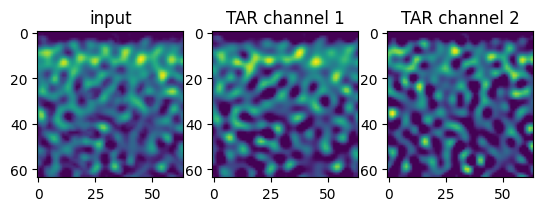

After Passing through Model


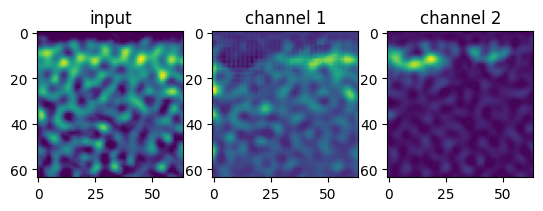

In [34]:
import matplotlib.pyplot as plt
idx = 15000
plt.subplot(131)
plt.title("input")
plt.imshow(test_dset[idx][0][0])
plt.subplot(132)
plt.title("TAR channel 1")
plt.imshow(test_dset[idx][1][0])
plt.subplot(133)
plt.title("TAR channel 2")
plt.imshow(test_dset[idx][1][1])
plt.show()
print("After Passing through Model")

inp = torch.from_numpy(test_dset[idx][0]).unsqueeze(0).to(next(model.parameters()).device)
# print(inp.shape)
rec, _ = model(inp)
if hasattr(model, "model") and hasattr(model.model, "predict_logvar"):
    if model.model.predict_logvar is not None:
        rec, _ = torch.chunk(rec, chunks=2, dim=1)
# Convert back to FP32 for stitching (more stable)
rec = rec.float()
# print(rec.shape)
plt.subplot(131)
plt.title("input")
plt.imshow(inp.cpu()[0,0])
plt.subplot(132)
plt.title("channel 1")
plt.imshow(rec.detach().cpu().numpy()[0,0])
plt.subplot(133)
plt.title("channel 2")
plt.imshow(rec.detach().cpu().numpy()[0,1])
plt.show()

In [ ]:
reduce_data = True
import copy
dset = copy.deepcopy(test_dset)
if reduce_data:
    print("Using REDUCED evaluation data for quick'n'dirty testing!")
    dset.reduce_data(t_list=[0])#, h_start = -dset._data.shape[-2]//4, w_start=-dset._data.shape[-2]//4)
else:
    print('Using the full set of evaluation data!')
    print(f'(More specifically, I will use {dset.get_num_frames()} frames for evaluations.)') 

Using REDUCED evaluation data for quick'n'dirty testing!
From inside set_img_sz of multich_dataset.py:
[LCMultiChDloader] Data Size (1, 4192, 4192, 2)
[LCMultiChDloader] Image size (patch size): 64
[LCMultiChDloader] Grid size: 32
[LCMultiChDloader] Using stride spatial: (4, 4)
WindowedTilingGridIndexManager initialized with data_shape: (1, 4192, 4192, 2),
WindowedTilingGridIndexManager initialized with patch_shape: (1, 64, 64, 2), stride: (1, 4, 4, 1)
  Dimension 0: data=4192, patch=64, inner_tile=32, stride=4 → 1033 patches
  Dimension 1: data=4192, patch=64, inner_tile=32, stride=4 → 1033 patches
  Grid counts for flat indexing: [1, 1033, 1033]
  Total patches: 1067089
[LCMultiChDloader] Windowed Index Manager initialisation complete

[LCMultiChDloader] Data reduced. New data shape: (1, 4192, 4192, 2)


In [ ]:
from tqdm.notebook import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt

def batched_generator_amp(model, loader, use_gpu_stitch=True, device=None):
    """
    Version with automatic mixed precision for faster inference.
    Use this if your model supports FP16.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model.eval()
    if not next(model.parameters()).is_cuda and device.type == "cuda":
        model.to(device)
    
    global_idx = 0
    
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for batch in tqdm(loader, desc="Generating predictions (AMP)", dynamic_ncols=True):
            if isinstance(batch, (list, tuple)):
                inp = batch[0]
            
            inp = inp.to(device, non_blocking=True)
            B = inp.shape[0]
            
            rec, _ = model(inp)
            
            # Handle logvar
            if hasattr(model, "model") and hasattr(model.model, "predict_logvar"):
                if model.model.predict_logvar is not None:
                    rec, _ = torch.chunk(rec, chunks=2, dim=1)
            
            # Convert back to FP32 for stitching (more stable)
            rec = rec.float()
            
            if global_idx//B % 50== 0:
                print("Input Shape:",inp.shape)
                print("Rec Shape:",rec.shape)
                #  Input Shape: torch.Size([1, 5, 64, 64])
                #  Rec Shape: torch.Size([3, 5, 64, 64])
                idx = -1
                plt.figure()
                plt.subplot(131)
                plt.imshow(inp[idx][0].cpu())
                plt.subplot(132)
                plt.imshow(rec.cpu()[idx][0].cpu())
                plt.subplot(133)
                plt.imshow(rec.cpu()[idx][1].cpu())
                plt.show()
            # Permute to channel-last
            rec = rec.permute(0, 2, 3, 1)

            if use_gpu_stitch:
                indices = torch.arange(global_idx, global_idx + B, 
                                      dtype=torch.long, device=device)
            else:
                rec = rec.cpu().numpy()
                indices = np.arange(global_idx, global_idx + B, dtype=np.int64)
            
            global_idx += B
            
            yield rec, indices

Computing all 2D locations...
Loaded 2D locations from cache
Precomputed all 2D locations in 0.02 secs


Generating predictions (AMP):   0%|          | 0/8337 [00:00<?, ?it/s]

Input Shape: torch.Size([128, 3, 64, 64])
Rec Shape: torch.Size([128, 2, 64, 64])


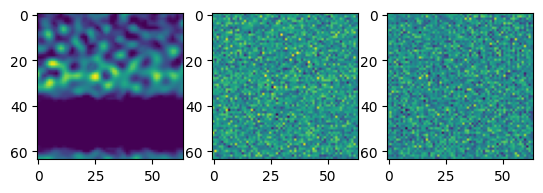

Input Shape: torch.Size([128, 3, 64, 64])
Rec Shape: torch.Size([128, 2, 64, 64])


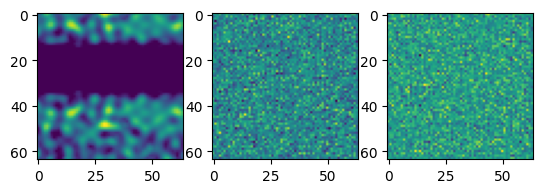

Input Shape: torch.Size([128, 3, 64, 64])
Rec Shape: torch.Size([128, 2, 64, 64])


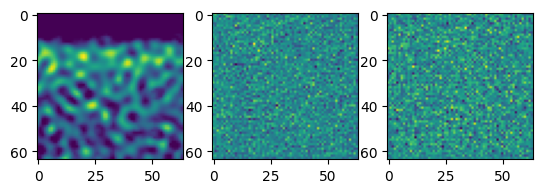

Input Shape: torch.Size([128, 3, 64, 64])
Rec Shape: torch.Size([128, 2, 64, 64])


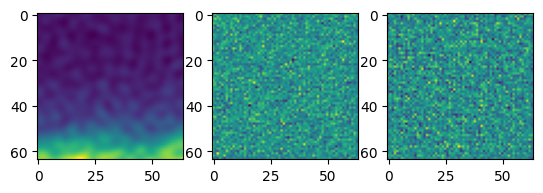

Input Shape: torch.Size([128, 3, 64, 64])
Rec Shape: torch.Size([128, 2, 64, 64])


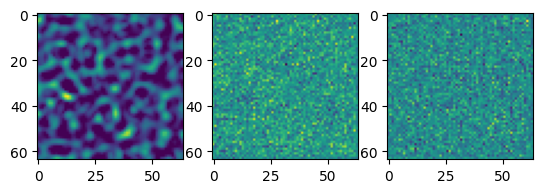

KeyboardInterrupt: 

In [ ]:
# Recommended setup
from torch.utils.data import DataLoader
from careamics.lvae_training import swt_stitching as swt

from careamics.lvae_training import swt_stitching as swt
dloader = DataLoader(
    dset,
    batch_size=8,  # Start with 50% increase
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=True,
    persistent_workers=True
)

gen_amp = batched_generator_amp(
    model,
    dloader,
    use_gpu_stitch=True
)

# Then run stitching
stitched, counts = swt.stitch_predictions_windowed(
    gen_amp,
    dset,
    inner_fraction=[0.5, 0.5],
    gpu = True
)
stitched = stitched.cpu().numpy()

In [ ]:
# load inputs and noisy targets (needed for plotting later on)
inp = get_input(dset).sum(-1)
tar = get_target(dset)

NameError: name 'get_input' is not defined

## Overview: visualize full <nobr>Micro$\mathbb{S}$plit</nobr> predictions...

In [ ]:
from microsplit_reproducibility.notebook_utils.custom_dataset_2D import full_frame_evaluation

frame_idx = 0
assert frame_idx < len(stitched_predictions), f"Frame index {frame_idx} out of bounds"

full_frame_evaluation(stitched_predictions[frame_idx], tar[frame_idx], inp[frame_idx])

## Detailed view on some (foreground) locations...
Below, we show few random foreground locations and the corresponding <nobr>Micro$\mathbb{S}$plit</nobr> predictions.

You can execute the cell multiple times and different randomly chosen locations will be plotted.

In [ ]:
import numpy as np
from microsplit_reproducibility.utils.utils import clean_ax
from microsplit_reproducibility.notebook_utils.HT_LIF24 import (
    pick_random_patches_with_content,
)
import matplotlib.pyplot as plt

img_sz = 128
rand_locations = pick_random_patches_with_content(tar, 128)
h_start = rand_locations[
    2, 0
]  # np.random.randint(stitched_predictions.shape[1] - img_sz)
w_start = rand_locations[
    2, 1
]  # np.random.randint(stitched_predictions.shape[2] - img_sz)

ncols = 5
nrows = min(len(rand_locations), 5)
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 3, nrows * 3))

for i, (h_start, w_start) in enumerate(rand_locations[:nrows]):
    ax[i, 0].imshow(inp[0, h_start : h_start + img_sz, w_start : w_start + img_sz])
    for j in range(ncols // 2):
        vmin = stitched_predictions[..., j].min()
        vmax = stitched_predictions[..., j].max()
        ax[i, 2 * j + 1].imshow(
            tar[0, h_start : h_start + img_sz, w_start : w_start + img_sz, j],
            vmin=vmin,
            vmax=vmax,
        )
        ax[i, 2 * j + 2].imshow(
            stitched_predictions[
                0, h_start : h_start + img_sz, w_start : w_start + img_sz, j
            ],
            vmin=vmin,
            vmax=vmax,
        )

ax[0, 0].set_title("Primary Input")
for i in range(2):  # 2 channel splitting
    ax[0, 2 * i + 1].set_title(f"Target Channel {i+1}")
    ax[0, 2 * i + 2].set_title(f"Predicted Channel {i+1}")

# reduce the spacing between the subplots
plt.subplots_adjust(wspace=0.03, hspace=0.03)
clean_ax(ax)

## *Optional:* manual inspection of the predictions
<div class="alert alert-block alert-info">
<b> Task:</b> Set <i>y_start</i>, <i>x_start</i>, and <i>crop_size</i> to inspect the predictions at a  location of your choice.
</div>

In [ ]:
import numpy as np

y_start = 750  # np.random.randint(stitched_predictions.shape[1] - crop_size)
x_start = 750  # np.random.randint(stitched_predictions.shape[2] - crop_size)
crop_size = 512

ncols = 3
nrows = 2
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 5))
ax[0, 0].imshow(inp[0, y_start : y_start + crop_size, x_start : x_start + crop_size])
for i in range(ncols - 1):
    vmin = stitched_predictions[..., i].min()
    vmax = stitched_predictions[..., i].max()
    ax[0, i + 1].imshow(
        tar[0, y_start : y_start + crop_size, x_start : x_start + crop_size, i],
        vmin=vmin,
        vmax=vmax,
    )
    ax[1, i + 1].imshow(
        stitched_predictions[
            0, y_start : y_start + crop_size, x_start : x_start + crop_size, i
        ],
        vmin=vmin,
        vmax=vmax,
    )

# disable the axis for ax[1,0]
ax[1, 0].axis("off")
ax[0, 0].set_title("Input")
ax[0, 1].set_title("Channel 1")
ax[0, 2].set_title("Channel 2")
# set y labels on the right for ax[0,2]
ax[0, 2].yaxis.set_label_position("right")
ax[0, 2].set_ylabel("Target")

ax[1, 2].yaxis.set_label_position("right")
ax[1, 2].set_ylabel("Predicted")

print("Here the crop you selected:")

# ***Optional Step 2.5:*** Posterior Sampling and MMSE Predictions
For a given input patch, <nobr>Micro$\mathbb{S}$plit</nobr> can generate multiple outputs. This is possible because <nobr>Micro$\mathbb{S}$plit</nobr> is learning a full posterior of possible solutions, which is a quite powerful feature!

As we elaborate in the <nobr>Micro$\mathbb{S}$plit</nobr> paper and also later in the calibration notebook `03_calibration.ipynb`, this allows users to visually judge and even quantify the (data) uncertainty in the predictions their trained model makes.

Below, we show two posterior samples and how much they differ for a few random foreground locations. Re-run the cell to see different randomly choosen locations and corresponding posterior samples.

### Get two posterior samples and plot them...

In [ ]:
from microsplit_reproducibility.notebook_utils.HT_LIF24 import show_sampling

imgsz = 3
ncols = 6
examplecount = 3
_, ax = plt.subplots(
    figsize=(imgsz * ncols, 2 * imgsz * examplecount),
    ncols=ncols,
    nrows=2 * examplecount,
)

show_sampling(dset, model, ax=ax[:2])
show_sampling(dset, model, ax=ax[2:4])
show_sampling(dset, model, ax=ax[4:6])
plt.tight_layout()

### The MMSE solution and why you should care...
You might hae spotted a few tiling artefacts here and there in the plots above. This is mainly caused by the fact that we are using a variational model that predicts samples from the learned posterior.

Without going into all the details, at tile-edges, the posterior samples are simply not 100% consistent (because the input is subject to uncertainties due to non-perfect inputs).

Either way, without even telling you, the predictions you computed above are not single samples as the ones we saw in the previous plot. Instead, we have created multiple posterior samples and averaged them pixel by pixel.

***But why would we do that?*** While a single posterior sample is one interpretation of the noisy and likely somewhat ambiguous input data, the Minimum Mean Square Error (MMSE) of the posterior is the expected value of the posterior. Immagine it as the average of all posteror samples!

Fun fact, if you train a U-Net with an L2 loss, the U-Net's predictions will also be an approximation of the MMSE. 👀

Anyways, the details can be confusing... the take-home message is:
**The more posterior samples you average, the closer will this average image be at the MMSE solution. MMSE solutions look nice and smooth, and they are relatively consistent when we compute tiled predictions.

All this is certainly not obvious and if you are interested to learn more, maybe check out [this](https://arxiv.org/abs/2401.01438) and [this](https://openaccess.thecvf.com/content/ICCV2023/papers/Ashesh_uSplit_Image_Decomposition_for_Fluorescence_Microscopy_ICCV_2023_paper.pdf)!

But enough -- **let's compare single posterior samples with some approximate MMSE solutions**!

In [ ]:
n_samples = 50  # min: 10
if n_samples < 10:
    n_samples = 10

# choose a random input patch
from microsplit_reproducibility.notebook_utils.HT_LIF24 import (
    pick_random_inputs_with_content,
)

idx_list = pick_random_inputs_with_content(dset)
inp_patch, tar_patch = dset[idx_list[0] + 1]

# compute individual posterior samples
samples = []
model.eval()
import torch

for _ in (range(n_samples), "Sampling the posterior"):
    with torch.no_grad():
        pred_patch, _ = model(torch.Tensor(inp_patch).unsqueeze(0).to(model.device))
        samples.append(pred_patch[0, : tar_patch.shape[0]].cpu().numpy())
samples = np.array(samples)

In [ ]:
inp_patch, tar_patch = dset[idx_list[0]]

nrows = 5
imgsz = 3
_, ax = plt.subplots(figsize=(imgsz * 2, imgsz * nrows + imgsz), ncols=2, nrows=nrows)
ax[0, 0].imshow(inp_patch[0])
ax[0, 0].set_title("Input (Idx: {})".format(idx_list[0]))

# first channel
ax[1, 0].imshow(samples[0, 0])
ax[1, 0].set_title("C1: Sample")
ax[2, 0].imshow(np.mean(samples[:5, 0], axis=0))
ax[2, 0].set_title("C1: MMSE (5)")
ax[3, 0].imshow(np.mean(samples[:, 0], axis=0))
ax[3, 0].set_title(f"C1: MMSE ({len(samples)})")
ax[4, 0].imshow(tar_patch[0])
ax[4, 0].set_title("C1: Target")

# second channel
ax[1, 1].imshow(samples[0, 1])
ax[1, 1].set_title("C2: Sample")
ax[2, 1].imshow(np.mean(samples[:5, 1], axis=0))
ax[2, 1].set_title("C2: MMSE (5)")
ax[3, 1].imshow(np.mean(samples[:, 1], axis=0))
ax[3, 1].set_title(f"C2: MMSE ({len(samples)})")
ax[4, 1].imshow(tar_patch[1])
ax[4, 1].set_title("C2: Target")

ax[0, 1].axis("off")

# **Step 2.6:** Saving data required for network calibration and error estimations (ie. for running `03_calibration.ipynb`)
We reached a point where we can train and use <nobr>Micro$\mathbb{S}$plit</nobr>. Only one key feature remains unexplored: the possibility to check how well calibrated a trained <nobr>Micro$\mathbb{S}$plit</nobr> network is, and then use multiple posterior samples to analyze their pixel-wise variability to ***estimate the true error*** with respect to unknown ground truth.

**Calibaration and error estimation will require:**<br>
***(i)*** target images as the one we used during training but for the *Test and Validation data* (we will store those in two files for later use),<br>
***(ii)*** saved MMSE predictions obtained with your trained model *on the Test and the Validation data* (also here we will store 2 files), and <br>
***(iii)*** saved pixel-wise standard deviations (Std) of the posterior samples we averaged to get the MMSE predictions from above (also on *Test and Validation data*, hence, yet another 2 files to be saved).

Once we created and saved all we need, the notebook `03_calibration.ipynb` does not have to deal with <nobr>Micro$\mathbb{S}$plit</nobr> models or predictions at all! 🥳

In [ ]:
# change this only if you used your own data
dataset_prefix = "custom_dataset_"  # TODO: fill in with your own dataset prefix

# create folder to store all the data (6 files in total) for the calibration notebook
path_for_calibration_data = f"calibration_data"
os.makedirs(path_for_calibration_data, exist_ok=True)

### ***Step 2.6.1:*** Save target data we need in the calibration notebook.
We need the training-data like target channels later in the calibration notebook, and since we have this data availabe right here, let's quickly save it into the folder we created above (the one that will contain the 6 files we talk about all the time).

In [ ]:
data_stats = experiment_params["data_stats"]
target_val = val_dset._data[...]
target_test = test_dset._data[...]

sep_mean = np.transpose(data_stats[0].numpy(), axes=(0, 2, 3, 1))
sep_std = np.transpose(data_stats[1].numpy(), axes=(0, 2, 3, 1))

target_val_normalized = (target_val - sep_mean) / sep_std
target_test_normalized = (target_test - sep_mean) / sep_std

# store also the corresponding target data (this is just like the supervision data we used during training)
target_val_filename = "target_" + dataset_prefix + "Val"
target_test_filename = "target_" + dataset_prefix + "Test"
tifffile.imwrite(
    f"{path_for_calibration_data}/{target_val_filename}.tif", target_val_normalized
)
print(
    f'✅ Saved target data for Val data at "{path_for_calibration_data}/{target_val_filename}.tif"!'
)
tifffile.imwrite(
    f"{path_for_calibration_data}/{target_test_filename}.tif", target_test_normalized
)
print(
    f'✅ Saved target data for Test data at "{path_for_calibration_data}/{target_test_filename}.tif"!'
)

### ***Step 2.6.2:*** Save the MMSE predictions and Std from Step 2.4.
Wee need four more things to have all the data for the calibration notebook together. More specifically, and as mentioned before, we need:
*(i)* the MMSE predictions for the Validation data, 
*(ii)* the MMSE predictions for the Test data,
*(iii)* the standard deviation (Std) of the posterior samples we drew to generate the MMSE predictions for the Validation data, and
*(iv)* the standard deviation (Std) of the posterior samples we drew to generate the MMSE predictions for the Test data.

Two of these four missing pieces we have computed above, depending on what you choose to work with, Validation or Training data (you made this choice in Step 2.1).
If you want to be prepared for the next notebook and haven't already, go back to Step 2.1, and set <i> evaluate_on_validation_data = True </i> and re-run the cells in the remainer of the notebook. Make sure `reduce_data` parameter setting is consistent. 

In [ ]:
# Let us make somewhat sure that this notebook is not in 'bad shape'
# (i) are the generated predictions of same shape?

assert (
    norm_stitched_predictions.shape == stitched_stds.shape
), "MMSE predictions and pixel-wise stds have incompatible shape. Please redo Step 2.4 of this notebook!"

target = test_dset._data[...]
assert (
    stitched_stds.shape == target.shape
), "Shape of predictions does not fit to shape of loaded inputs. Please check that the notebook is in a consistent state!"

# check if user predicted on validation or test data
val_or_test = "Val" if evaluate_on_validation_data else "Test"

# print what we found for user
print(
    f"✅ Looks like predictions for {val_or_test} data were created above.\nWe will save those predictions in the next cell..."
)
the_other = "Test" if evaluate_on_validation_data else "Val"

In [ ]:
# store the predictions currently available in this notebook (created in Step 2.4 (predictions))
pred_filename = "prediction_" + dataset_prefix + val_or_test
std_filename = "std_" + dataset_prefix + val_or_test
# save only one prediction
tifffile.imwrite(
    f"{path_for_calibration_data}/{pred_filename}.tif", norm_stitched_predictions
)
print(
    f'✅ Saved MMSE predictions for {val_or_test} data at "{path_for_calibration_data}/{pred_filename}.tif"!'
)
tifffile.imwrite(f"{path_for_calibration_data}/{std_filename}.tif", stitched_stds)
print(
    f'✅ Saved posterior sample Stds for {val_or_test} data at "{path_for_calibration_data}/{pred_filename}.tif"!'
)

print(
    f"\n‼️ Please ensure to also create and save these two files also for the {the_other} data!"
)
print(
    f'You are only ready for the calibration notebook once the folder "{path_for_calibration_data}" contain 6 files in total!'
)

**If 6 files (dataset name will differ) like the ones show below are in the above mentioned folder you are done here! 👍**
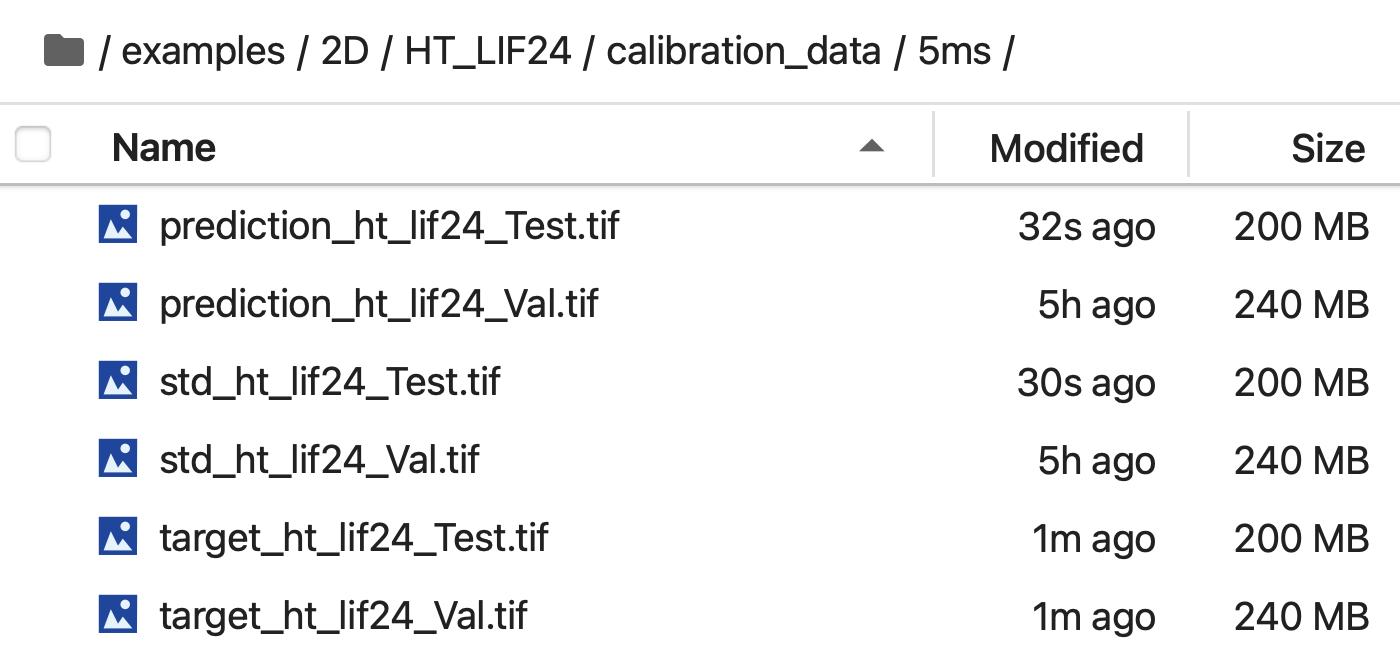
### Congratulations, done, that is fantastic! 🎉